Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, Semester Two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data, using the methods you have learned about in this course and in this program, and draw interesting conclusions. 

For Week 3, include concepts such as linear regression with forward and backward selection, PCR, and PLSR. Complete your Jupyter Notebook homework by 11:59 pm ET on Sunday. 

In Week 7, you will compile your findings from your Jupyter Notebook homework into your Milestone One assignment for grading. For full instructions and the rubric for Milestone One, refer to the following link. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone


In [2]:
import pandas as pd
from src.load_data import load_wisconsin, load_brazil, split_X_y
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [3]:
df_wisc, target = load_wisconsin()
X_wisc, y_wisc = split_X_y(df_wisc, target)

X_train, X_test, y_train, y_test = train_test_split(
    X_wisc, y_wisc, test_size=0.2, random_state=42, stratify=y_wisc
)


In [4]:
##### PCA works naturally in a pipeline because it is an X-only transformer: it fits component directions from X and returns transformed X components.
##### Logistic regression then uses those transformed X components as the final classifier.
##### PLSR is different because it uses both X and y when fitting its target-informed components.
##### I used a small class wrapper to make PLSR behave like a pipeline-compatible transformer: fit with X and y, then return only the transformed X scores.
##### This lets forward selection, PCR, and PLSR use the same pipeline/GridSearchCV/CV workflow.

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin


class PLSTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X, y):
        self.pls_ = PLSRegression(n_components=self.n_components)
        self.pls_.fit(X, y)
        return self

    def transform(self, X):
        return self.pls_.transform(X)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_logreg = LogisticRegression(
    max_iter=10000,
    solver="saga",
    random_state=42
)

pipelines = {
    "forward_selection": Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SequentialFeatureSelector(
            estimator=LogisticRegression(max_iter=10000, solver="saga", random_state=42),
            direction="forward",
            scoring="roc_auc",
            cv=3,
            n_jobs=-1
        )),
        ("model", base_logreg)
    ]),

    "pcr": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("model", base_logreg)
    ]),

    "plsr": Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSTransformer()),
        ("model", base_logreg)
    ])
}

param_grids = {
    "forward_selection": {
        "selector__n_features_to_select": [5, 10, 15],
        "model__C": [0.1, 1, 10],
        "model__penalty": ["l2"]
    },

    "pcr": {
        "pca__n_components": [2, 3, 5, 10, 15],
        "model__C": [0.1, 1, 10],
        "model__penalty": ["l2"]
    },

    "plsr": {
        "pls__n_components": [2, 3, 5, 10, 15],
        "model__C": [0.1, 1, 10],
        "model__penalty": ["l2"]
    }
}

In [7]:
wisc_results = []
wisc_best_models = {}

for name, pipe in pipelines.items():
    print(f"\nRunning {name}...")

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    wisc_best_models[name] = best_model

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    wisc_results.append({
        "model": name,
        "best_cv_roc_auc": search.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, y_proba),
        "best_params": search.best_params_
    })

wisc_results_df = pd.DataFrame(wisc_results).sort_values("best_cv_roc_auc", ascending=False)
wisc_results_df



Running forward_selection...
Fitting 5 folds for each of 9 candidates, totalling 45 fits



Running pcr...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Running plsr...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


,model,best_cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,best_params
2,plsr,0.995769,0.991228,1.000000,0.976190,0.987952,0.997354,"{'model__C': 1, 'model__penalty': 'l2', 'pls__..."
1,pcr,0.995150,0.982456,1.000000,0.952381,0.975610,0.997024,"{'model__C': 1, 'model__penalty': 'l2', 'pca__..."
0,forward_selection,0.994840,0.956140,0.974359,0.904762,0.938272,0.994709,"{'model__C': 1, 'model__penalty': 'l2', 'selec..."


### Wisconsin summary

On Wisconsin, all three Week 3 approaches performed well, which is consistent with the rest of the project: the dataset is small, clean, and already highly separable. Forward selection remained the most interpretable because it kept original predictors, while PCR and PLSR offered alternative ways to handle correlation through lower-dimensional components.


### Brazil comparison

To satisfy Milestone 1 breadth, I also applied forward selection, PCR, and PLSR to the Brazil dataset. I used an 8,000-row sample here to keep the notebook runnable while still testing the same Week 3 ideas on the larger, more imbalanced dataset.


In [8]:
df_brazil, target_brazil = load_brazil(sample_size=8000, random_state=42)
X_brazil, y_brazil = split_X_y(df_brazil, target_brazil)

X_train_brazil, X_test_brazil, y_train_brazil, y_test_brazil = train_test_split(
    X_brazil, y_brazil, test_size=0.2, random_state=42, stratify=y_brazil
)

brazil_results = []
brazil_best_models = {}

for name, pipe in pipelines.items():
    print(f"\nRunning Brazil {name}...")

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train_brazil, y_train_brazil)

    best_model = search.best_estimator_
    brazil_best_models[name] = best_model

    y_pred = best_model.predict(X_test_brazil)
    y_proba = best_model.predict_proba(X_test_brazil)[:, 1]

    brazil_results.append({
        "model": name,
        "best_cv_roc_auc": search.best_score_,
        "test_accuracy": accuracy_score(y_test_brazil, y_pred),
        "test_precision": precision_score(y_test_brazil, y_pred, zero_division=0),
        "test_recall": recall_score(y_test_brazil, y_pred, zero_division=0),
        "test_f1": f1_score(y_test_brazil, y_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test_brazil, y_proba),
        "best_params": search.best_params_
    })

brazil_results_df = pd.DataFrame(brazil_results).sort_values("best_cv_roc_auc", ascending=False)
brazil_results_df



Running Brazil forward_selection...
Fitting 5 folds for each of 9 candidates, totalling 45 fits



Running Brazil pcr...
Fitting 5 folds for each of 15 candidates, totalling 75 fits



Running Brazil plsr...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


,model,best_cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,best_params
0,forward_selection,0.928155,0.944375,0.706897,0.362832,0.479532,0.913400,"{'model__C': 10, 'model__penalty': 'l2', 'sele..."
2,plsr,0.927942,0.942500,0.684211,0.345133,0.458824,0.917968,"{'model__C': 0.1, 'model__penalty': 'l2', 'pls..."
1,pcr,0.921272,0.939375,0.637931,0.327434,0.432749,0.906743,"{'model__C': 10, 'model__penalty': 'l2', 'pca_..."


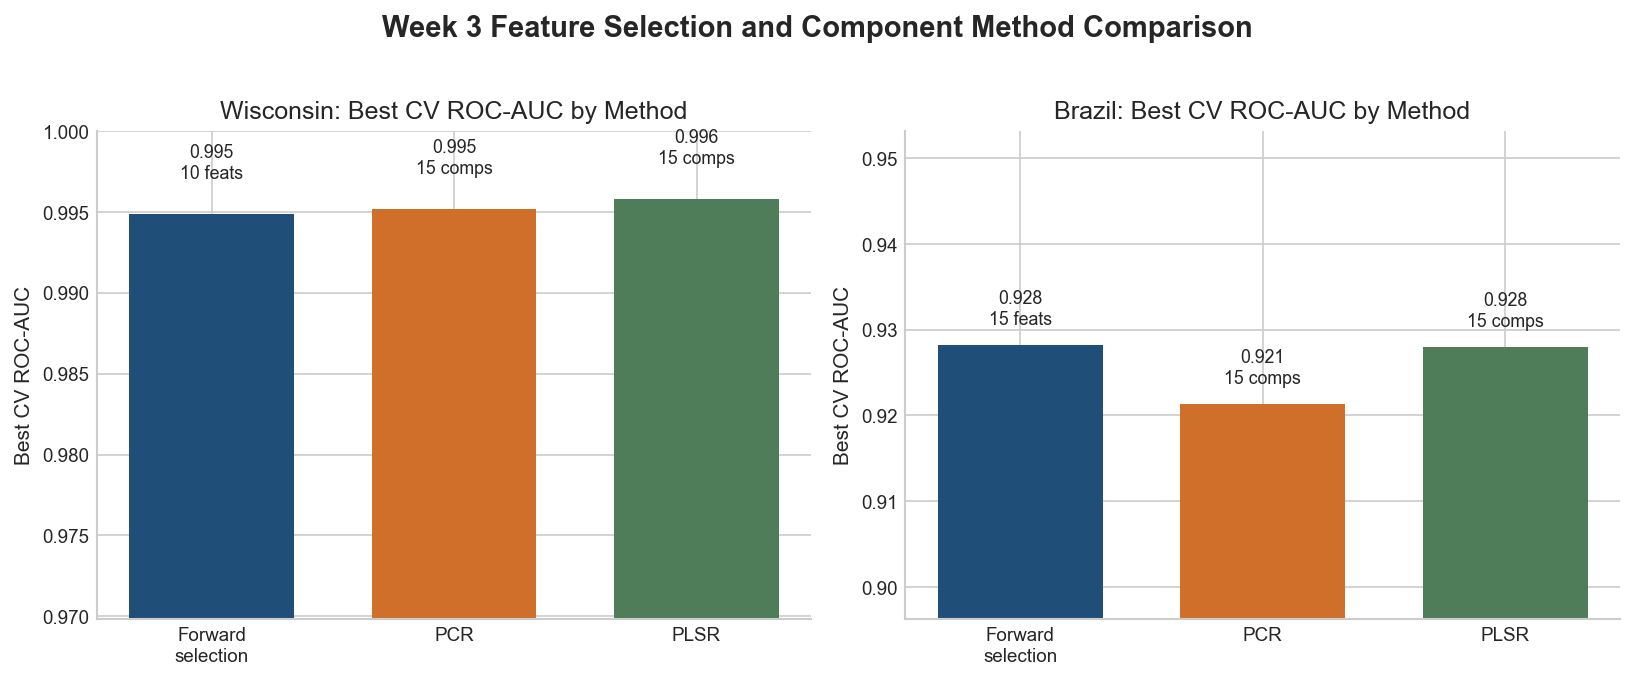

In [9]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "milestone1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def extract_model_size(best_params):
    if "selector__n_features_to_select" in best_params:
        return f"{best_params['selector__n_features_to_select']} feats"
    if "pca__n_components" in best_params:
        return f"{best_params['pca__n_components']} comps"
    if "pls__n_components" in best_params:
        return f"{best_params['pls__n_components']} comps"
    return ""

plot_order = ["forward_selection", "pcr", "plsr"]
pretty_names = {
    "forward_selection": "Forward\nselection",
    "pcr": "PCR",
    "plsr": "PLSR",
}
plot_frames = [
    ("Wisconsin", wisc_results_df.set_index("model").loc[plot_order].reset_index()),
    ("Brazil", brazil_results_df.set_index("model").loc[plot_order].reset_index()),
]
colors = ["#1F4E79", "#D06F2A", "#4F7D5A"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=False)
for ax, (dataset_name, plot_df) in zip(axes, plot_frames):
    labels = [pretty_names[name] for name in plot_df["model"]]
    bars = ax.bar(labels, plot_df["best_cv_roc_auc"], color=colors, width=0.68)
    ax.set_title(f"{dataset_name}: Best CV ROC-AUC by Method")
    ax.set_ylabel("Best CV ROC-AUC")
    y_min = max(0, plot_df["best_cv_roc_auc"].min() - 0.025)
    y_max = min(1.0, plot_df["best_cv_roc_auc"].max() + 0.025)
    ax.set_ylim(y_min, y_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        size_label = extract_model_size(row["best_params"])
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            row["best_cv_roc_auc"] + 0.002,
            f"{row['best_cv_roc_auc']:.3f}\n{size_label}",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

fig.suptitle("Week 3 Feature Selection and Component Method Comparison", fontsize=14, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig03_feature_selection_pcr_plsr.png", bbox_inches="tight", facecolor="white")
plt.show()


### Combined Week 3 summary

Across both datasets, Week 3 reinforced the tradeoff between interpretability and component-based dimensionality reduction. Forward selection stayed the most interpretable because it selected original features directly, while PCR and PLSR compressed the predictors into a smaller number of components. On Wisconsin, all three methods were very strong and close together, which makes sense for a clean and highly separable dataset.

Brazil was more informative because the differences were easier to see. The best cross-validated ROC-AUC came from the stronger component-based approaches, while forward selection remained easier to explain in original-variable terms. That makes Week 3 useful for the Milestone 1 breadth section: component methods can help generalization when the feature space is larger and more correlated, but feature selection still has an advantage when interpretability matters.
